In [1]:
from DatabankLib.protein_functions import *
import yaml

#databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


In [22]:
import yaml
import matplotlib.pyplot as plt
import numpy as np

def read_saxs_yaml(filename):
    """Read q and I(q) data from a SAXS YAML file with flexible key names."""
    with open(filename, 'r') as f:
        data = yaml.safe_load(f)

    q, I, I_std = [], [], []

    for d in data:
        # q key
        q_val = d.get('q[1/A]', d.get('q', None))
        if q_val is None:
            continue

        # Intensity key – support different possible names
        I_key_candidates = ['mean_I(q)[a.u.]', 'mean_Inten[a.u.]', 'I(q)[a.u.]']
        I_val = None
        for key in I_key_candidates:
            if key in d:
                I_val = d[key]
                break
        if I_val is None:
            continue

        # Optional standard deviation
        sd_val = d.get('sd_I(q)[a.u.]', d.get('sd_Inten[a.u.]', None))

        q.append(q_val)
        I.append(I_val)
        I_std.append(sd_val if sd_val is not None else 0.0)

    return np.array(q), np.array(I), np.array(I_std)


def plot_saxs_comparison(saxs_file, maicos_file):
    """Compare SAXS and SAXS_MAICoS YAML files."""
    # Read both files
    q_saxs, I_saxs, I_std = read_saxs_yaml(saxs_file)
    q_maicos, I_maicos, _ = read_saxs_yaml(maicos_file)

    # Normalize for shape comparison
    if np.max(I_maicos) > 0:
        scale = np.max(I_saxs) / np.max(I_maicos)
    else:
        scale = 1.0
    I_maicos_scaled = I_maicos * scale


    # Plot
    plt.figure(figsize=(7, 5))
    plt.errorbar(q_saxs, I_saxs, yerr=I_std, fmt='o-', label='SAXS (reference)', alpha=0.8)
    plt.plot(q_maicos, I_maicos_scaled, 's--', label='SAXS (MAICoS, scaled)', alpha=0.8)

    plt.yscale('log')
    plt.xlabel(r"$q$ (1/Å)")
    plt.ylabel(r"$I(q)$ (a.u.)")
    plt.title("SAXS Comparison: Reference vs MAICoS")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# Example usage:
# plot_saxs_comparison("SAXS.yaml", "SAXS_MAICoS.yaml")


asyn [['replica_02_AMBER03WS_md_2000ns.xtc']] 87


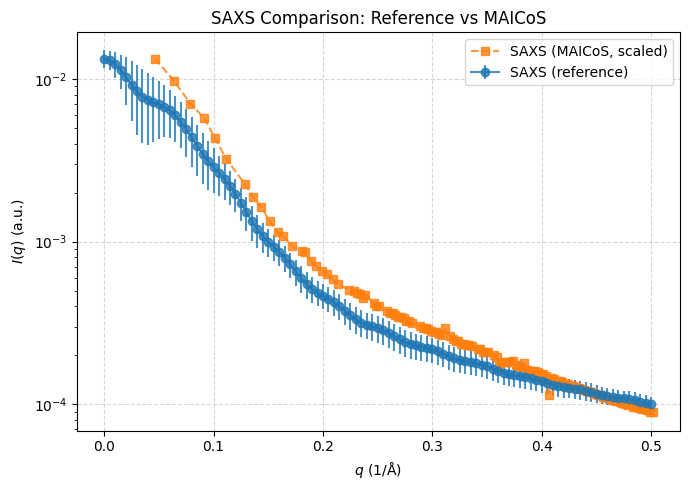

asyn [['replica_04_DESAMBER_md_2000ns.xtc']] 93


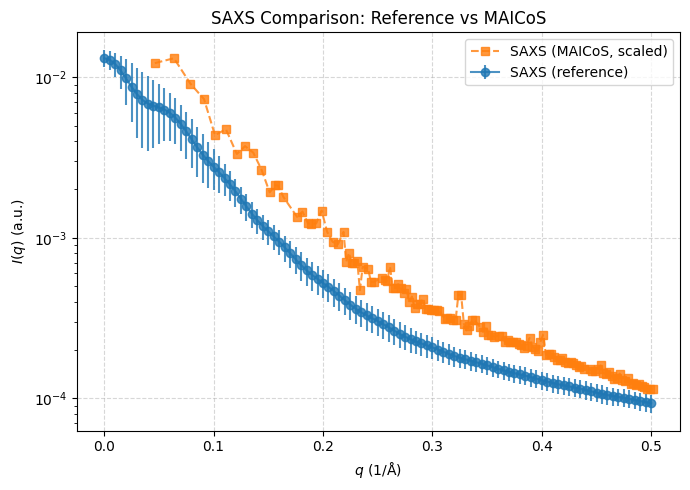

KRS1-72 [['replica_01_AMBER03WS_md_2000ns.xtc']] 99


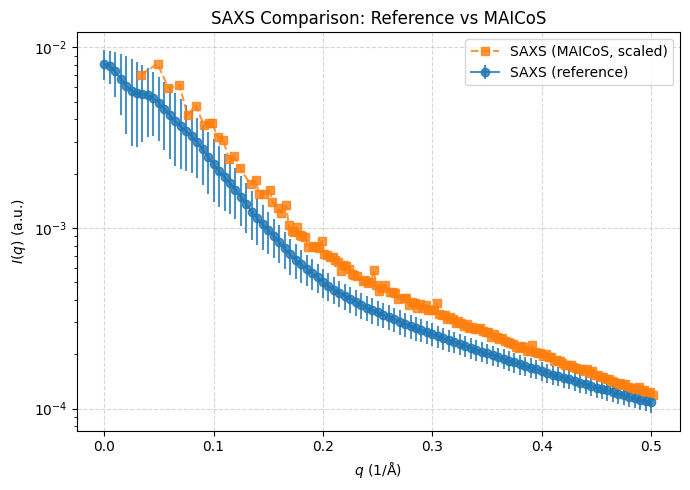

asyn [['replica_04_CHARMM36M_md_2000ns.xtc']] 90


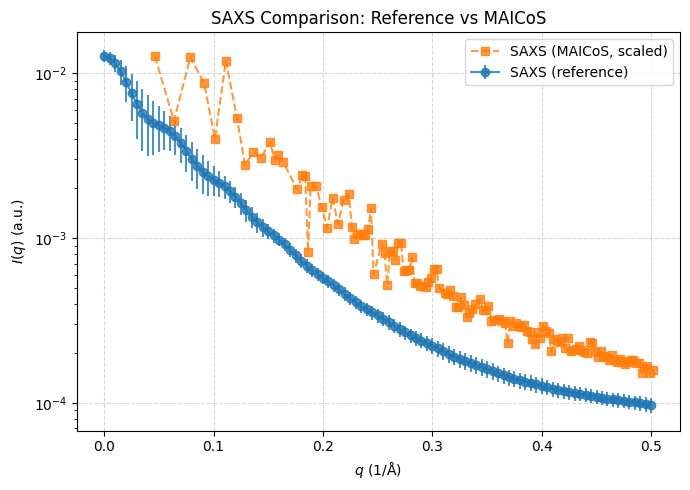

asyn [['replica_01_DESAMBER_md_2000ns.xtc']] 71


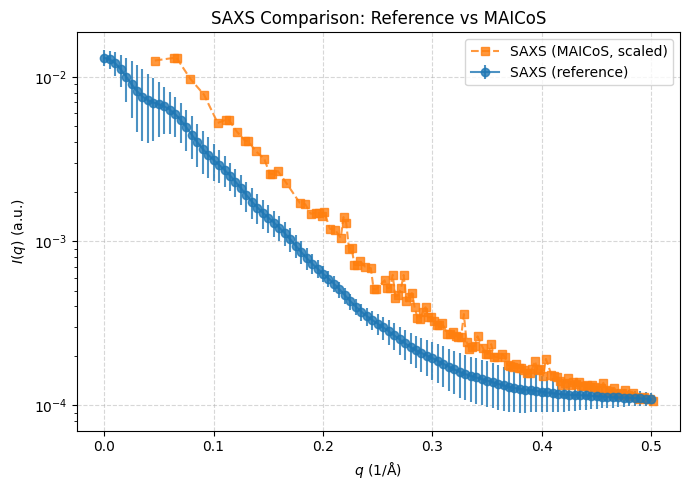

asyn [['replica_03_DESAMBER_md_2000ns.xtc']] 76


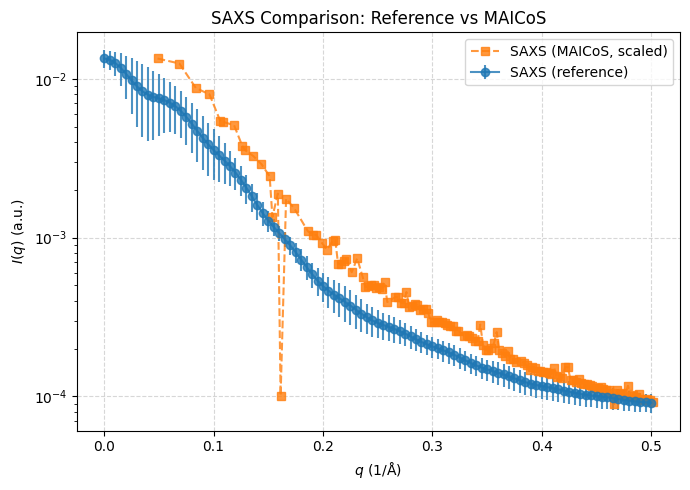

Calmodulin [['md_calmodulin_DESamber_model10_nojump.xtc']] 51


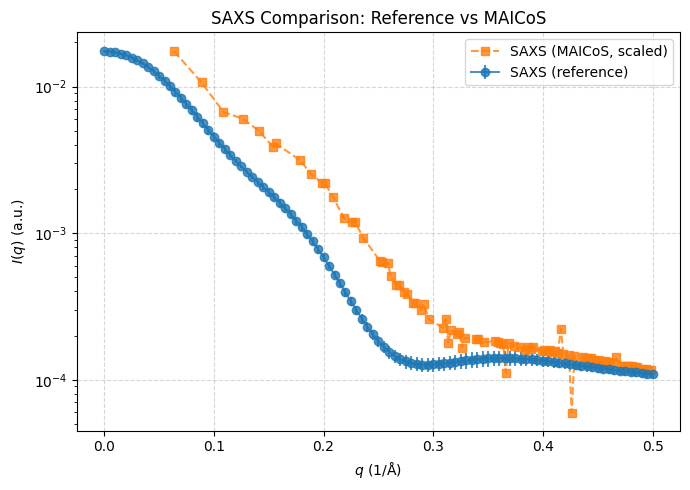

asyn [['replica_05_CHARMM36M_md_2000ns.xtc']] 88


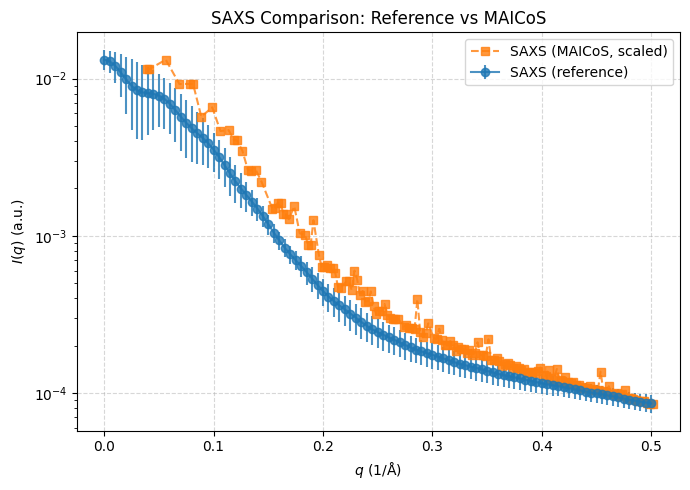

asyn [['replica_01_CHARMM36M_md_2000ns.xtc']] 61


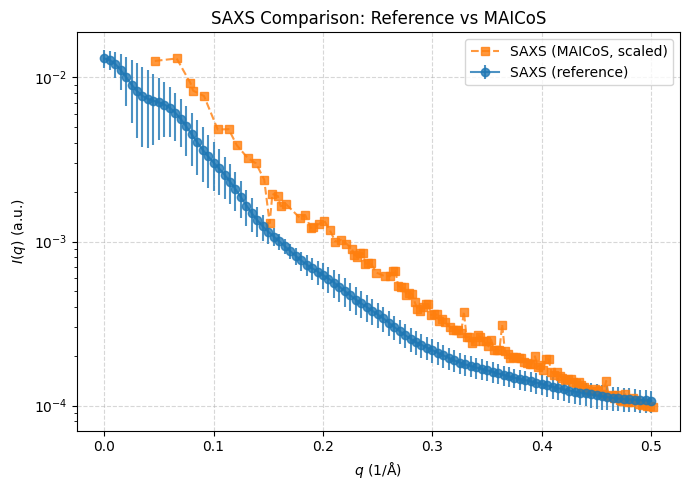

asyn [['replica_04_AMBER99SB-DISP_md_2000ns.xtc']] 65


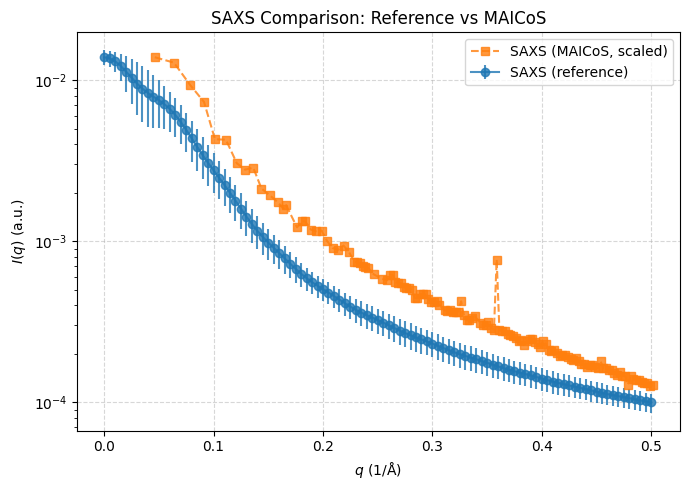

asyn [['replica_01_AMBER99SB-DISP_md_2000ns.xtc']] 66


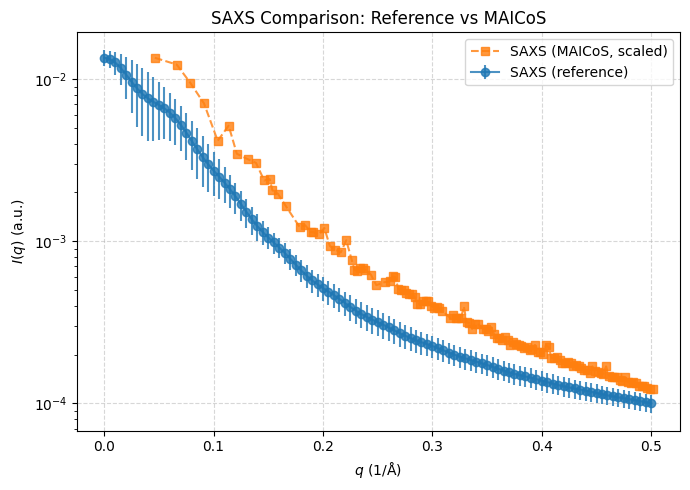

asyn [['replica_05_AMBER99SB-DISP_md_2000ns.xtc']] 73


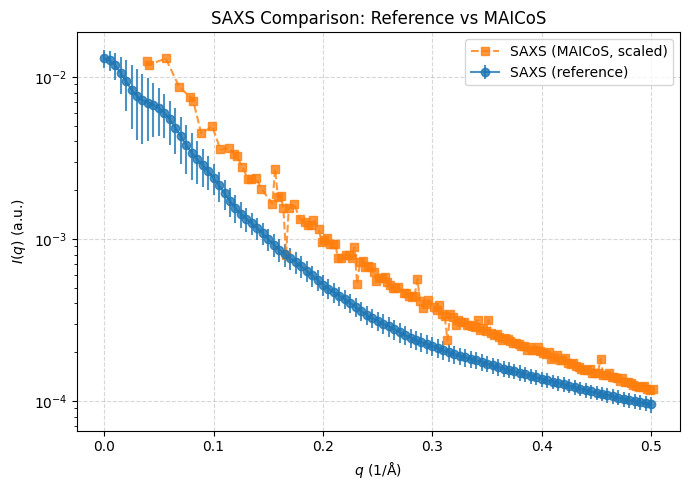

asyn [['replica_04_AMBER99SBWS_md_2000ns.xtc']] 69


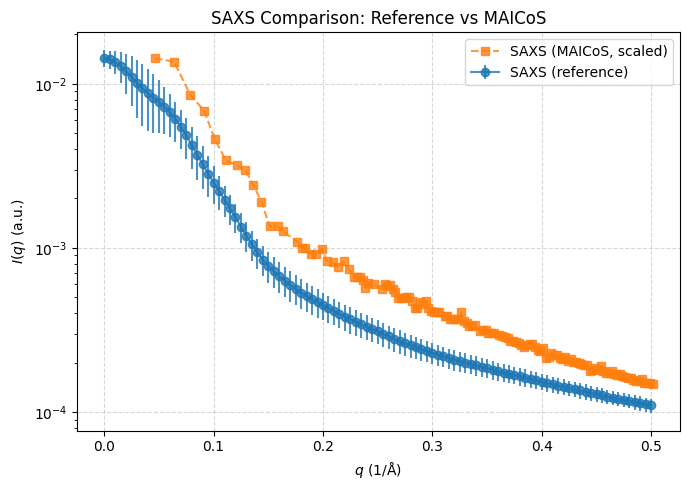

asyn [['replica_02_CHARMM36M_md_2000ns.xtc']] 57


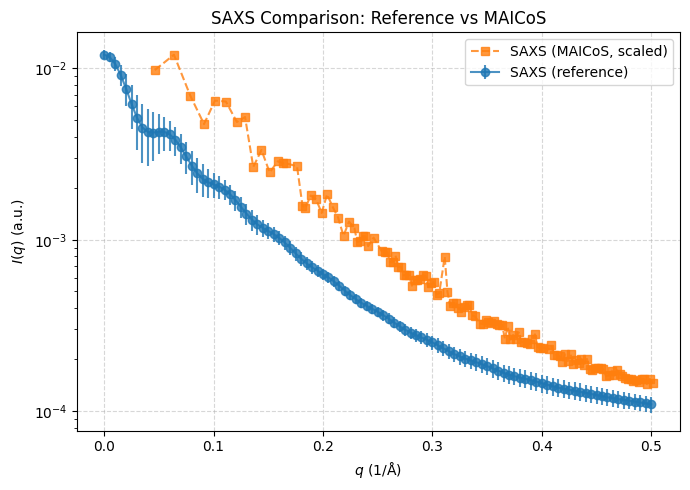

asyn [['replica_05_DESAMBER_md_2000ns.xtc']] 91


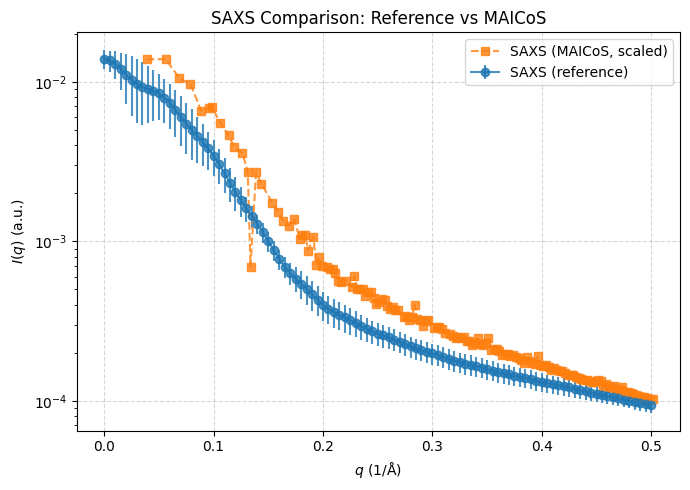

ChiZ1-64 [['replica_01_AMBER03WS_md_1500ns.xtc']] 100


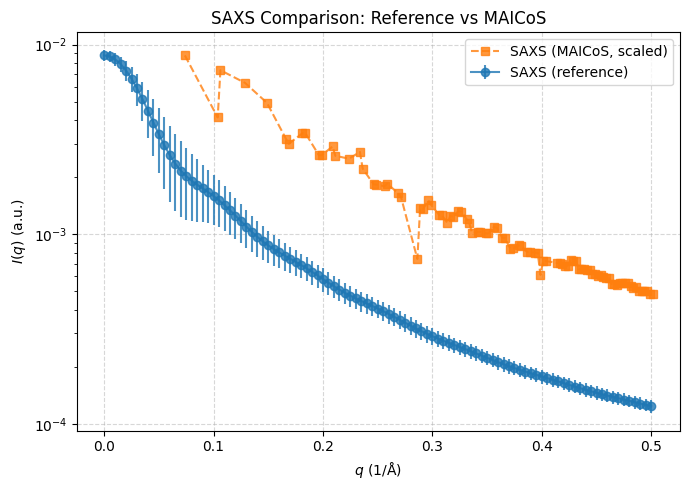

asyn [['replica_01_AMBER99SBWS_md_2000ns.xtc']] 98


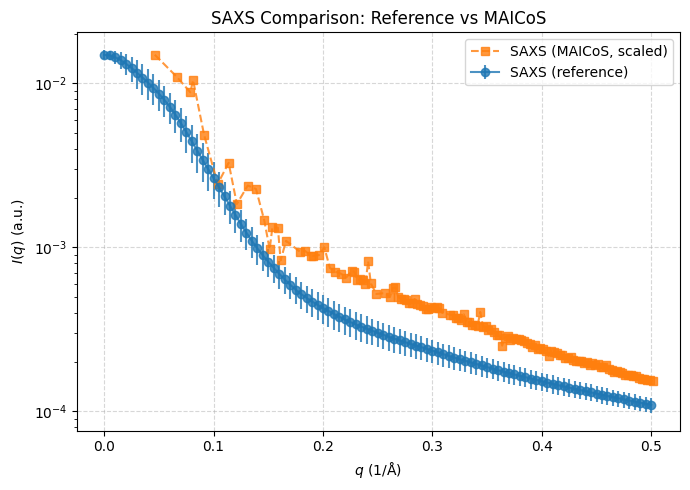

EN2 [['md2_EN2_amber99SBws_model1_nojump.xtc']] 42


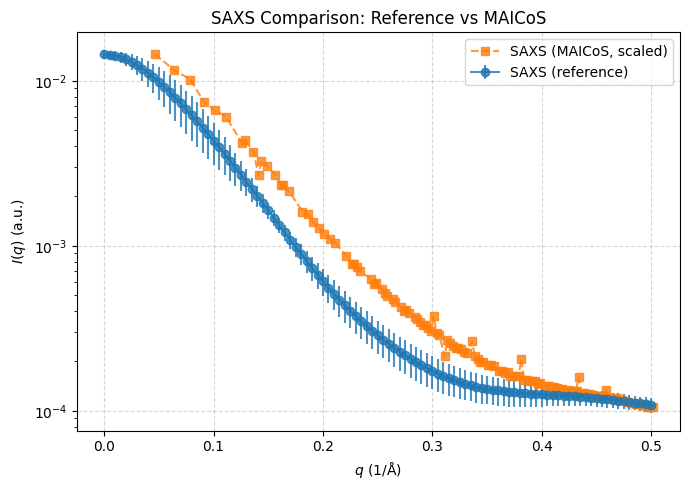

asyn [['replica_02_AMBER99SBWS_md_2000ns.xtc']] 63


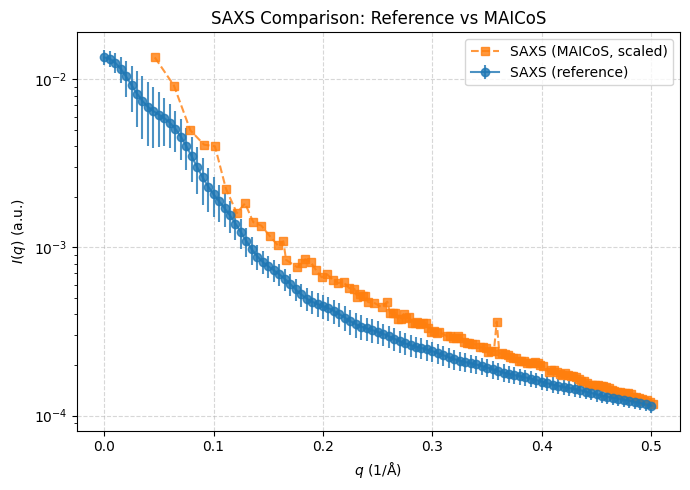

asyn [['replica_04_AMBER03WS_md_2000ns.xtc']] 77


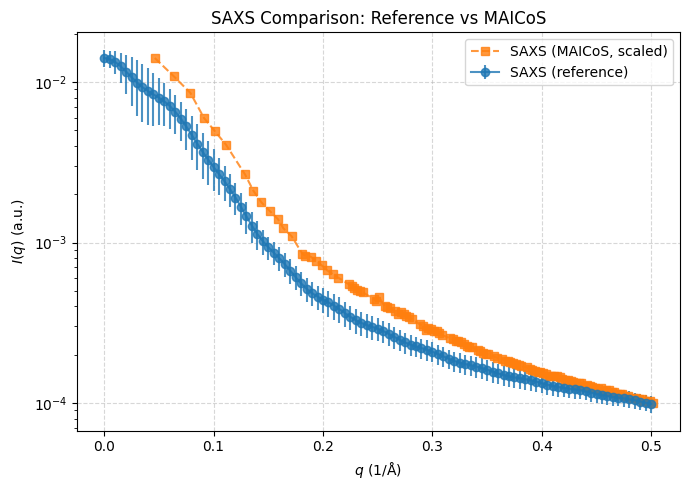

asyn [['replica_03_AMBER03WS_md_2000ns.xtc']] 81


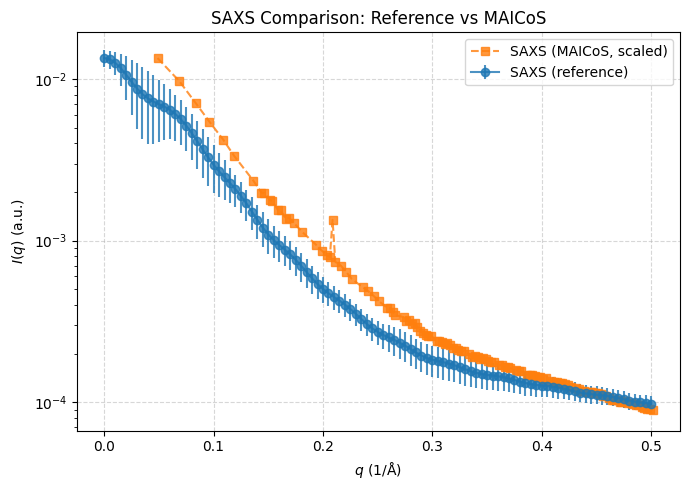

asyn [['replica_03_CHARMM36M_md_2000ns.xtc']] 74


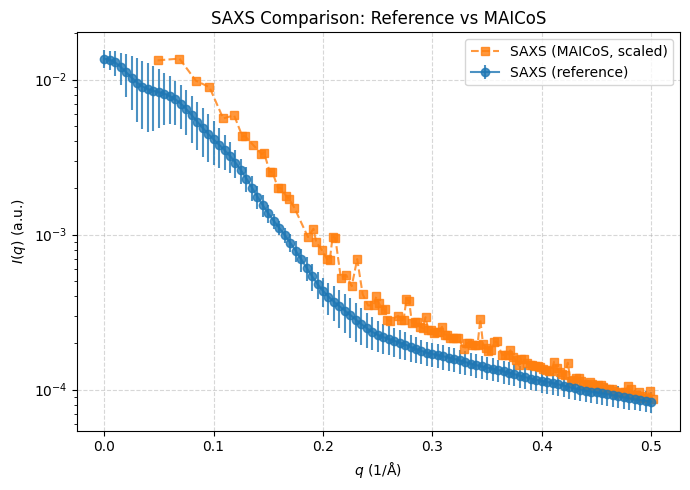

asyn [['replica_03_AMBER99SB-DISP_md_2000ns.xtc']] 89


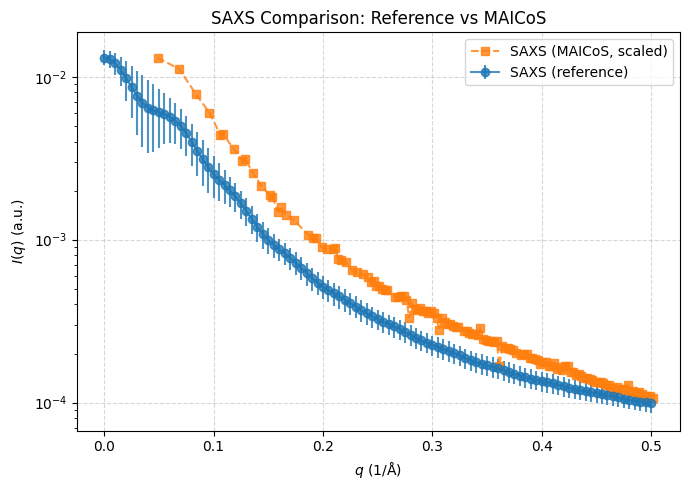

icl2 [['replica_01_AMBER03WS_md_2000ns.xtc']] 101


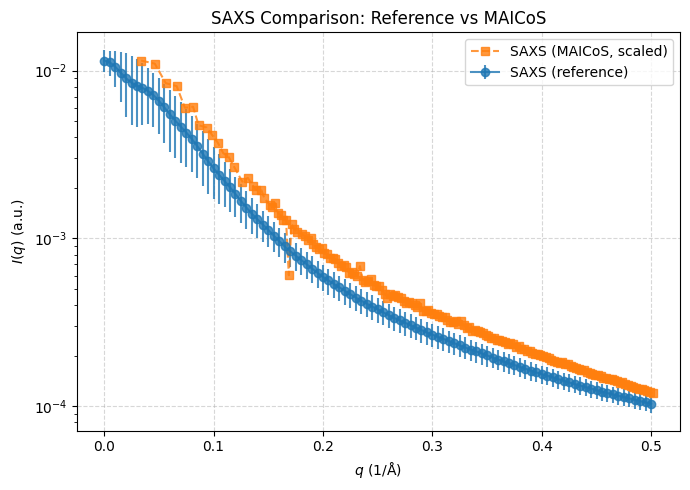

asyn [['replica_05_AMBER99SBWS_md_2000ns.xtc']] 86


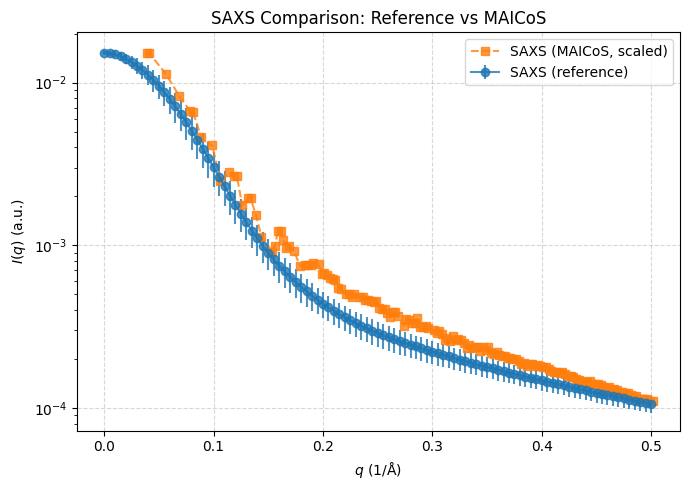

asyn [['replica_01_AMBER03WS_md_2000ns.xtc']] 102


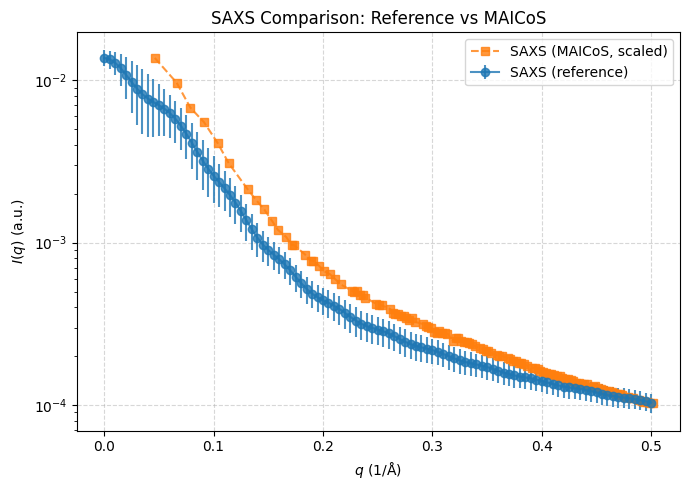

asyn [['replica_03_AMBER99SBWS_md_2000ns.xtc']] 52


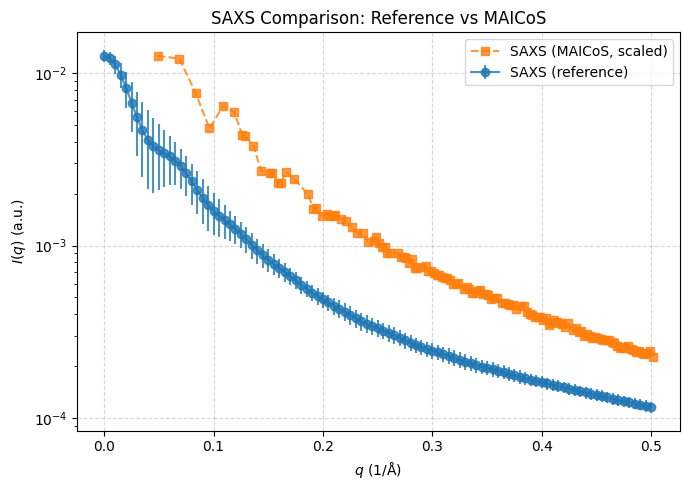

asyn [['replica_02_AMBER99SB-DISP_md_2000ns.xtc']] 53


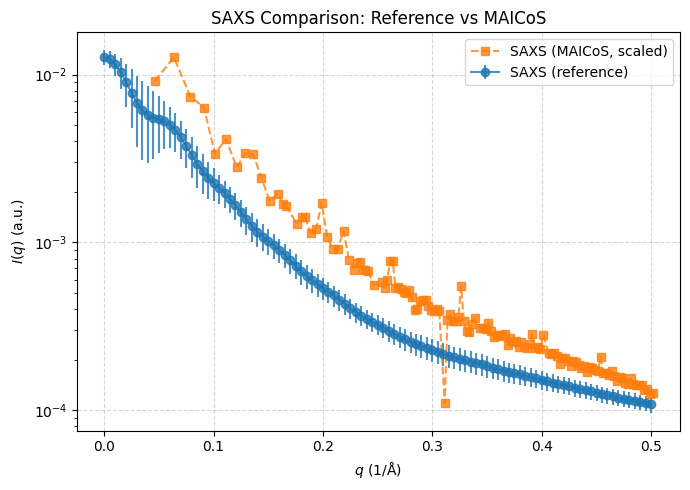

asyn [['replica_05_AMBER03WS_md_2000ns.xtc']] 92


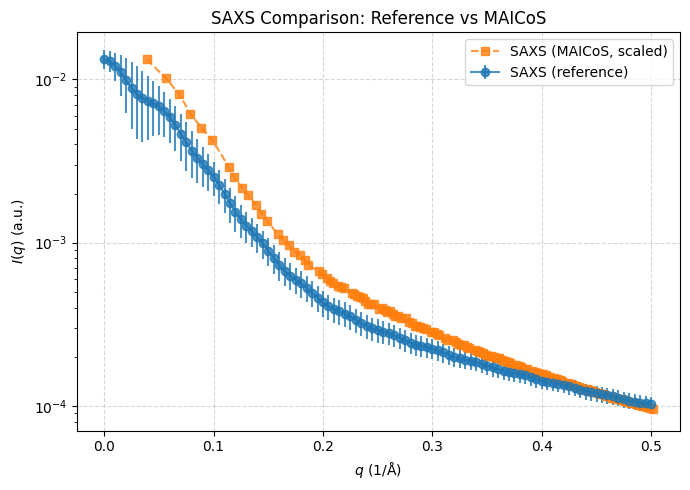

asyn [['replica_02_DESAMBER_md_2000ns.xtc']] 62


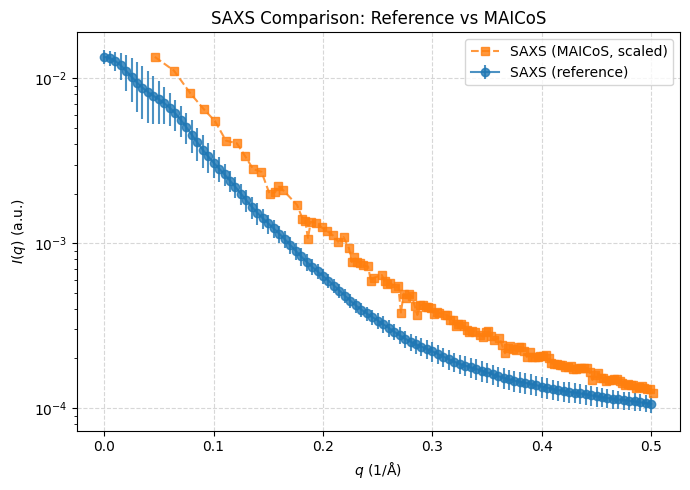

In [23]:
for system in systems:
    SAXS_file = databankPath + 'Data/Simulations/' + system['path'] + 'SAXS.yaml'
    SAXS_MAICOS_file = databankPath + 'Data/Simulations/' + system['path'] + 'SAXS_MAICoS.yaml'
    if os.path.exists(SAXS_file) and os.path.exists(SAXS_MAICOS_file):
        print(system['SYSTEM'], system['TRJ'], system['ID'])
        plot_saxs_comparison(SAXS_file, SAXS_MAICOS_file)
        
        